# Colab 0
## Bombing operations in Vietnam War

In [1]:
import pyspark
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

In [2]:
sparkConf = SparkConf().set("spark.ui.port", "4050")
sparkContext = pyspark.SparkContext(conf = sparkConf)
spark = SparkSession.builder.getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/03 22:58:46 WARN Utils: Your hostname, panteliss-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.255.221.4 instead (on interface en0)
26/02/03 22:58:46 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/03 22:58:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Load the datasets and print their schema ###

In [4]:
Bombing_Operations = spark.read.json("../../assets/datasets/Bombing_Operations.json")
Aircraft_Glossary = spark.read.json("../../assets/datasets/Aircraft_Glossary.json")

In [ ]:
Bombing_Operations.printSchema()
Aircraft_Glossary.printSchema()

In [ ]:
# get a sample
Bombing_Operations.take(3)
Aircraft_Glossary.show(10)

### Question1: How many countries are involved and in how many missions?

In [5]:
missionTargetCounts = Bombing_Operations.groupBy("TargetCountry").count().withColumnRenamed("count","Missions Count").orderBy("Missions Count")
missionTargetCounts.show()

+--------------+--------------+
| TargetCountry|Missions Count|
+--------------+--------------+
|   PHILLIPINES|             1|
|       UNKNOWN|            59|
|WESTPAC WATERS|            74|
|      THAILAND|         60486|
|      CAMBODIA|        218788|
| NORTH VIETNAM|        694269|
|          LAOS|       1254695|
| SOUTH VIETNAM|       2172403|
+--------------+--------------+



In [6]:
Bombing_Operations.createOrReplaceTempView("Bombing_Operations")
query = "SELECT ContryFlyingMission , count(*) as MissionCount FROM Bombing_Operations GROUP BY ContryFlyingMission ORDER BY MissionCount DESC"
missionCounts = spark.sql(query)
mcdf = missionCounts.toPandas()

In [ ]:
pl = mcdf.plot(kind = 'bar', log = True, alpha = 0.5,x = 'ContryFlyingMission', y = 'MissionCount', legend = False)
pl.set_xlabel("Country")
pl.set_ylabel("Mission Count")
pl.set_title("Mission Count by Country")
#plt.show()

### Question 2: Show the number of missions in time for each of the countries involved

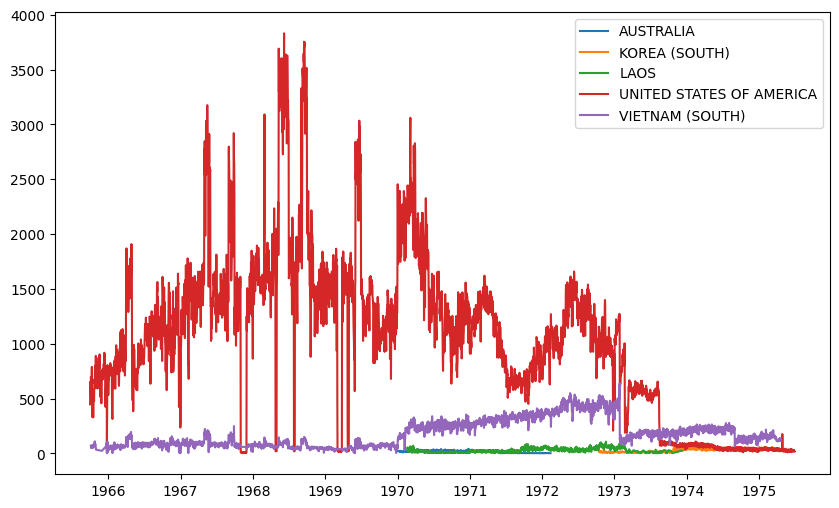

In [7]:
missionCountries = Bombing_Operations.selectExpr(["to_date(MissionDate) as MDate", "ContryFlyingMission"])
missionByDate = missionCountries.groupBy(["MDate", "ContryFlyingMission"]).count().withColumnRenamed("count","Missions").orderBy("MDate").toPandas()
fg = plt.figure(figsize = (10, 6))
for country, missions in missionByDate.groupby("ContryFlyingMission"):
    plt.plot(missions["MDate"], missions["Missions"], label = country)
plt.legend(loc='best')
plt.show()

### Question 3: Who bombed this location?

In [8]:
jun_29_operations = Bombing_Operations.where("MissionDate = '1966-06-29' AND TargetCountry = 'NORTH VIETNAM'")
jun_29_p = jun_29_operations.groupBy("ContryFlyingMission").count().withColumnRenamed("count","MissionCount").orderBy("MissionCount").toPandas()

jun_29_operations.cache()
jun_29_operations.write.mode("overwrite").json("assets/results/colab0/jun_29_operations.json")

In [ ]:
#jun_29_operations = spark.read.json("assets/results/colab0/jun_29_operations.json")
allLocations = jun_29_operations.groupBy("TakeoffLocation").count().orderBy("count", ascending = False)
allLocations.show()

In [ ]:
allLocs = jun_29_operations.rdd.map(lambda x: (x.TakeoffLocation, 1)).reduceByKey(lambda x, y: x + y)
allLocsDF = spark.createDataFrame(allLocs)
allLocsDF.show()

### Question 4: What is the most used aircraft type?

In [9]:
missionJoined = Bombing_Operations.join(Aircraft_Glossary, Bombing_Operations.AirCraft == Aircraft_Glossary.AirCraft)
missionAircrafts = missionJoined.select("AirCraftType")
missionAircrafts.groupBy("AirCraftType").count().orderBy("count", ascending = False).show()

+--------------------+-------+
|        AirCraftType|  count|
+--------------------+-------+
|  Fighter Jet Bomber|1073126|
|         Fighter Jet| 882594|
|  Jet Fighter Bomber| 451385|
|     Attack Aircraft| 315246|
|Light ground-atta...| 267457|
|  Fighter bomber jet| 242231|
|Military Transpor...| 228426|
|  Utility Helicopter| 146653|
|    Strategic bomber|  99100|
|     Tactical Bomber|  82219|
|Observation Aircraft|  81820|
|Fixed wing ground...|  75058|
|Ground attack air...|  73843|
|Carrier-based Fig...|  58691|
|   Training Aircraft|  48435|
|       Light fighter|  39999|
|        Light Bomber|  39262|
|Light Tactical Bo...|  34738|
| Light Utility Plane|  28582|
|Observation/ Ligh...|  24491|
+--------------------+-------+
only showing top 20 rows
